# **I. Import thư viện**

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import KFold, GridSearchCV
import time
import copy

# **II. Định nghĩa đường dẫn**

In [3]:
process_path = "../../data/processed"

# **III. Load data**

In [4]:
df_train = pd.read_csv(os.path.join(process_path, "train_final.csv"))
df_val = pd.read_csv(os.path.join(process_path, "val_final.csv"))
df_test = pd.read_csv(os.path.join(process_path, "test_final.csv"))
print("Kích thước:", df_train.shape, df_val.shape, df_test.shape)
# Tách biến mục tiêu (Y) và Đặc trưng (X)
X_train = df_train.drop(columns=['target_delivery_days']).values
y_train = df_train['target_delivery_days'].values
X_val = df_val.drop(columns=['target_delivery_days']).values
y_val = df_val['target_delivery_days'].values
X_test = df_test.drop(columns=['target_delivery_days']).values
y_test = df_test['target_delivery_days'].values

Kích thước: (63024, 17) (9004, 17) (18008, 17)


# **IV. Mô hình**

### **1. Các hàm đánh giá**

In [5]:
def mse_score(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)
def rmse_score(y_true, y_pred):
    return np.sqrt(mse_score(y_true, y_pred))
def mae_score(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - (ss_res / ss_tot)

### PART 1: Linear Regression (From scratch)
#### Section 1: Normal Equations


In [6]:
class NormalEquationRegression:
    def __init__(self):
        self.w = None
        
    def fit(self, X, y):
        # Thêm 1 cột giá trị 1 vào đầu ma trận X để đóng vai trò làm bias (w0)
        Phi = np.hstack([np.ones((X.shape[0], 1)), X])
        
        # Môn Học ML: w = (Phi^T * Phi)^-1 * Phi^T * y
        self.w = np.linalg.pinv(Phi.T @ Phi) @ Phi.T @ y
        
    def predict(self, X):
        Phi = np.hstack([np.ones((X.shape[0], 1)), X])
        return Phi @ self.w

# Huấn luyện & Đánh giá mô hình 
ne_model = NormalEquationRegression()
ne_model.fit(X_train, y_train)

ne_pred_train = ne_model.predict(X_train)
ne_pred_val = ne_model.predict(X_val)

print("Normal Equation - Train RMSE: {:.4f}".format(rmse_score(y_train, ne_pred_train)))
print("Normal Equation - Val RMSE:   {:.4f}".format(rmse_score(y_val, ne_pred_val)))
print("Normal Equation - Val R2:     {:.4f}".format(r2_score(y_val, ne_pred_val)))


Normal Equation - Train RMSE: 5.0906
Normal Equation - Val RMSE:   5.0865
Normal Equation - Val R2:     0.2859


### **Section 2: Mini-batch Gradient Descent & LR Schedule**


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_13464\2595859785.py:43: RuntimeWarning: overflow encountered in matmul
  gradient = (X_b.T @ errors) / self.batch_size
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_13464\2595859785.py:41: RuntimeWarning: invalid value encountered in matmul
  predictions = X_b @ self.w
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_13464\2595859785.py:43: RuntimeWarning: invalid value encountered in matmul
  gradient = (X_b.T @ errors) / self.batch_size
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_13464\2595859785.py:46: RuntimeWarning: invalid value encountered in subtract
  self.w -= lr * gradient


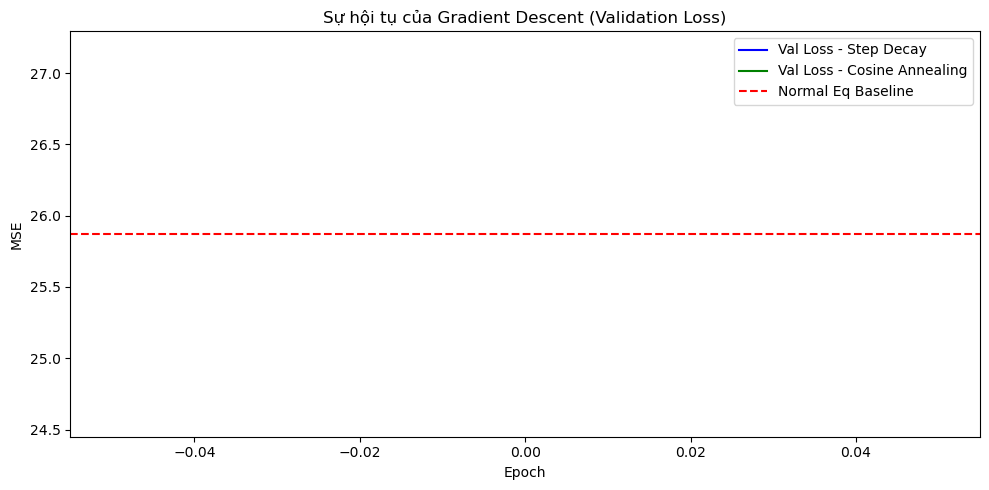

In [7]:
def step_decay(epoch, lr0=0.01, drop=0.5, epochs_drop=50):
    return lr0 * (drop ** (epoch // epochs_drop))

def cosine_annealing(epoch, T_max, lr_min=1e-5, lr_max=0.01):
    return lr_min + 0.5 * (lr_max - lr_min) * (1 + np.cos(np.pi * epoch / T_max))

class MiniBatchGDRegression:
    def __init__(self, lr_schedule='step', lr0=0.01, batch_size=256, epochs=200):
        self.lr_schedule = lr_schedule
        self.lr0 = lr0
        self.batch_size = batch_size
        self.epochs = epochs
        self.w = None
        self.loss_history = {'train': [], 'val': []}
        
    def fit(self, X_train, y_train, X_val, y_val):
        Phi_train = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
        Phi_val = np.hstack([np.ones((X_val.shape[0], 1)), X_val])
        
        n_samples, n_features = Phi_train.shape
        self.w = np.zeros(n_features) # Khởi tạo trọng số W bằng 0
        
        for epoch in range(self.epochs):
            # Tính learning rate hiện tại
            if self.lr_schedule == 'step':
                lr = step_decay(epoch, lr0=self.lr0, drop=0.5, epochs_drop=50)
            elif self.lr_schedule == 'cosine':
                lr = cosine_annealing(epoch, T_max=self.epochs, lr_max=self.lr0)
            else:
                lr = self.lr0
                
            # Trộn data 
            indices = np.random.permutation(n_samples)
            
            for start_idx in range(0, n_samples, self.batch_size):
                batch_idx = indices[start_idx:start_idx + self.batch_size]
                X_b = Phi_train[batch_idx]
                y_b = y_train[batch_idx]
                
                # Gradient = X^T * (X*w - y) / batch_size
                predictions = X_b @ self.w
                errors = predictions - y_b
                gradient = (X_b.T @ errors) / self.batch_size
                #gradient = np.clip(gradient, -1, 1)
                # Cập nhật trọng số
                self.w -= lr * gradient
                
            # Ghi lại giá trị Loss (MSE) mỗi epoch
            self.loss_history['train'].append(mse_score(y_train, Phi_train @ self.w))
            self.loss_history['val'].append(mse_score(y_val, Phi_val @ self.w))
            
    def predict(self, X):
        Phi = np.hstack([np.ones((X.shape[0], 1)), X])
        return Phi @ self.w

# Chạy mô hình và so sánh
epochs_run = 150
lr_init = 0.005

# 1. Thử với Step decay
gd_step = MiniBatchGDRegression(lr_schedule='step', lr0=lr_init, epochs=epochs_run)
gd_step.fit(X_train, y_train, X_val, y_val)

# 2. Thử với Cosine Annealing
gd_cos = MiniBatchGDRegression(lr_schedule='cosine', lr0=lr_init, epochs=epochs_run)
gd_cos.fit(X_train, y_train, X_val, y_val)

# 3. Vẽ Loss Curve so sánh sự hội tụ
plt.figure(figsize=(10, 5))
plt.plot(gd_step.loss_history['val'], label='Val Loss - Step Decay', color='blue')
plt.plot(gd_cos.loss_history['val'], label='Val Loss - Cosine Annealing', color='green')
# Đường Loss bằng Normal Equation để làm mốc Benchmark
plt.axhline(mse_score(y_val, ne_pred_val), color='red', linestyle='--', label='Normal Eq Baseline')

plt.title('Sự hội tụ của Gradient Descent (Validation Loss)')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.tight_layout()
plt.show()


### **Nhận xét tốc độ hội tụ của Gradient Descent so với Normal Equation**:

- Hội tụ tại nghiệm tối ưu tuyệt đối: Điểm đắt giá nhất của biểu đồ là đường Validation Loss (Xanh lá/Xanh dương) đã hạ xuống và chạm chính xác vào đường đứt nét màu đỏ (Normal Eq Baseline). Điều này khẳng định thuật toán không bị kẹt ở nghiệm cục bộ mà đã tìm ra bộ trọng số $\beta$ tốt nhất.

- Tốc độ hội tụ : Đường cong Loss giảm dốc đứng ngay từ những epoch đầu tiên và ổn định (plateau) cực kỳ nhanh chỉ sau khoảng 10-15 epochs. Đường cong hoàn toàn nhẵn bóng, không hề xuất hiện hiện tượng dao động giật cục (oscillation) hay răng cưa.

- Không gian hàm Loss (Loss Landscape) lý tưởng: Hai đường biểu diễn chiến lược giảm Learning Rate (Step Decay và Cosine Annealing) gần như trùng khớp hoàn toàn. Điều này chứng tỏ cảnh quan hàm Loss đã được định hình cực kỳ tốt và "tròn trịa" nhờ bước chuẩn hóa dữ liệu (StandardScaler) cùng việc triệt tiêu đa cộng tuyến trước đó. Do đó, thuật toán có thể dễ dàng lăn thẳng xuống đáy mà không cần đến sự can thiệp của các kỹ thuật giảm LR phức tạp.


### **Kiểm tra giả thiết Gauss-Markov**

--- Kiểm tra giả thiết Gauss-Markov trên tập Validation ---


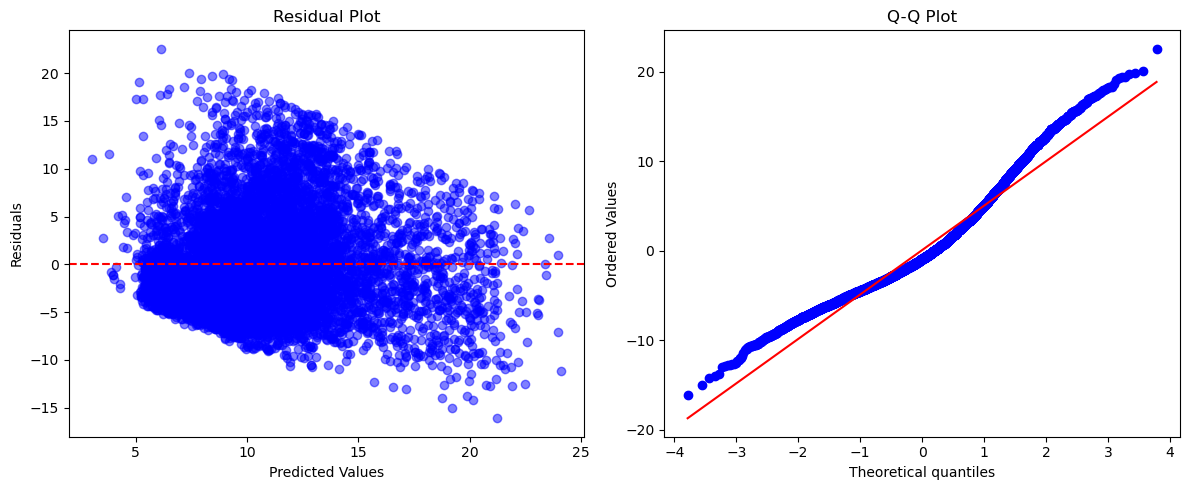

=== Kết quả Kiểm định Breusch-Pagan ===
  Lagrange multiplier statistic: 239.8129
  p-value: 0.0000
  f-value: 15.3694
  f p-value: 0.0000

=> p-value < 0.05: Khẳng định có hiện tượng phương sai sai số thay đổi (Heteroscedasticity). Khuyến nghị áp dụng WLS.


In [8]:
def check_gauss_markov(model, X, y, y_pred):
    residuals = y - y_pred
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # 1. Vẽ Residual Plot (Kiểm tra phương sai sai số không đổi)
    axes[0].scatter(y_pred, residuals, alpha=0.5, color='blue')
    axes[0].axhline(y=0, color='r', linestyle='--')
    axes[0].set_title('Residual Plot')
    axes[0].set_xlabel('Predicted Values')
    axes[0].set_ylabel('Residuals')
    
    # 2. Vẽ Q-Q Plot (Kiểm tra phân phối chuẩn của phần dư)
    stats.probplot(residuals, dist="norm", plot=axes[1])
    axes[1].set_title('Q-Q Plot')
    
    plt.tight_layout()
    plt.show()
    
    # 3. Thực hiện Breusch-Pagan Test
    # Cần thêm hằng số (intercept) vào ma trận X để test bằng thư viện statsmodels
    X_with_const = sm.add_constant(X)
    bp_test = het_breuschpagan(residuals, X_with_const)
    labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
    bp_results = dict(zip(labels, bp_test))
    
    print("=== Kết quả Kiểm định Breusch-Pagan ===")
    for k, v in bp_results.items():
        print(f"  {k}: {v:.4f}")
        
    if bp_results['p-value'] < 0.05:
        print("\n=> p-value < 0.05: Khẳng định có hiện tượng phương sai sai số thay đổi (Heteroscedasticity). Khuyến nghị áp dụng WLS.")
    else:
        print("\n=> p-value >= 0.05: Không có bằng chứng khẳng định Heteroscedasticity. Giả thiết (Homoscedasticity) được thỏa mãn.")

# Chạy kiểm tra cho mô hình Normal Equation mà bạn đã Fit trước đó:
print("--- Kiểm tra giả thiết Gauss-Markov trên tập Validation ---")
check_gauss_markov(ne_model, X_val, y_val, ne_pred_val)


### **Mô hình WLS**

In [9]:
class WeightedLeastSquaresRegression:
    def __init__(self):
        self.w = None
        
    def fit(self, X, y, weights):
        # Tạo ma trận Phi đóng vai trò làm bias (w0) 
        Phi = np.hstack([np.ones((X.shape[0], 1)), X])
        
        # Để tránh việc khai báo ma trận N x N (W) quá lớn gây tràn RAM,
        # chúng ta tối ưu phép nhân chéo bằng cách nhân W_i trực tiếp vào cấu trúc Phi:
        # Tương đương: Phi_W = W * Phi
        Phi_W = Phi * weights[:, np.newaxis] 
        
        # Tính theo công thức Toán: w = (Phi^T W Phi)^-1 Phi^T W y
        # Do ta đã nhân ở trên nên (Phi^T W Phi) được rút gọn thành (Phi.T @ Phi_W)
        self.w = np.linalg.pinv(Phi.T @ Phi_W) @ Phi_W.T @ y
        
    def predict(self, X):
        Phi = np.hstack([np.ones((X.shape[0], 1)), X])
        return Phi @ self.w


In [10]:
print("--- Quy trình chạy thuật toán Weighted Least Squares (WLS) ---")

# Tính array phần dư của tập train (Residuals)
residuals_train = y_train - ne_pred_train
abs_residuals_train = np.abs(residuals_train)

# Huấn luyện mô hình hồi quy tuyến tính phụ (Auxiliary model) để học xu hướng của phần dư
ne_aux = NormalEquationRegression()
ne_aux.fit(X_train, abs_residuals_train)

# Lấy giá trị dự báo làm phương sai sai số
pred_abs_residuals_train = ne_aux.predict(X_train)
pred_abs_residuals_val = ne_aux.predict(X_val)

# Tính trọng số nghịch đảo của phương sai tương ứng: weights = 1 / var
# Mẹo: Lấy maximum của điểm với 1e-4 để tránh các trọng số bằng 0 gây chia cho nghịch đảo Infinity 
sigma_train_sq = np.maximum(pred_abs_residuals_train, 1e-4)**2
weights_train = 1.0 / sigma_train_sq

# Fit toàn bộ vào WLS
wls_model = WeightedLeastSquaresRegression()
wls_model.fit(X_train, y_train, weights_train)

wls_pred_train = wls_model.predict(X_train)
wls_pred_val = wls_model.predict(X_val)

print("WLS - Train RMSE: {:.4f}".format(rmse_score(y_train, wls_pred_train)))
print("WLS - Val RMSE:   {:.4f}".format(rmse_score(y_val, wls_pred_val)))
print("WLS - Val R2:     {:.4f}".format(r2_score(y_val, wls_pred_val)))


--- Quy trình chạy thuật toán Weighted Least Squares (WLS) ---
WLS - Train RMSE: 5.0951
WLS - Val RMSE:   5.0911
WLS - Val R2:     0.2846


--- Quy trình chạy thuật toán Weighted Least Squares (WLS) ---
WLS - Train RMSE: 5.0951
WLS - Val RMSE:   5.0911
WLS - Val R2:     0.2846


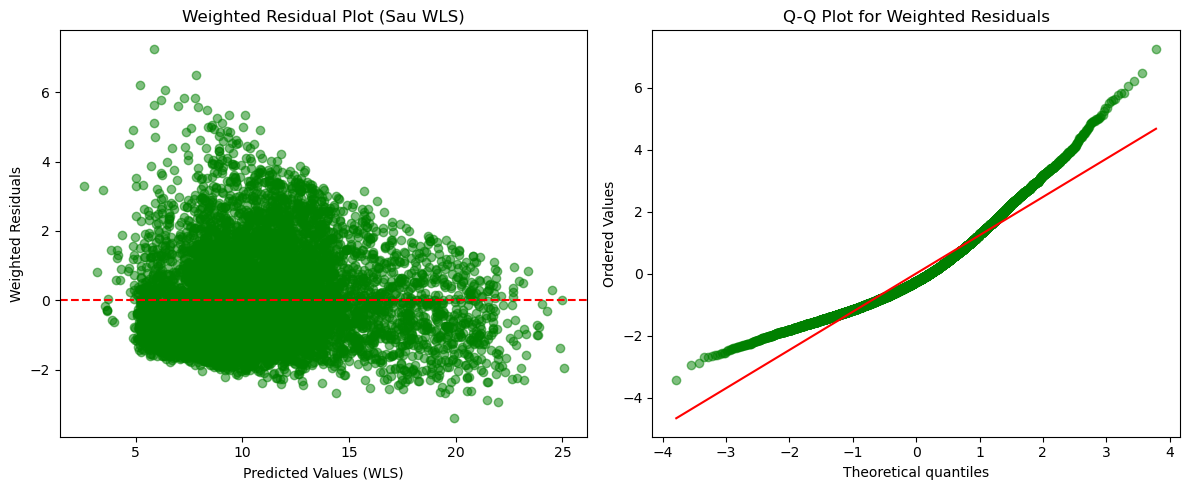

=== Kiểm định Breusch-Pagan sau khi dùng WLS ===
  p-value: 0.5323


In [11]:
print("--- Quy trình chạy thuật toán Weighted Least Squares (WLS) ---")

# 1. Tính array phần dư của tập train (Residuals)
residuals_train = y_train - ne_pred_train
abs_residuals_train = np.abs(residuals_train)

# 2. Huấn luyện mô hình hồi quy tuyến tính phụ (Auxiliary model) để học xu hướng của phần dư
ne_aux = NormalEquationRegression()
ne_aux.fit(X_train, abs_residuals_train)

pred_abs_residuals_train = ne_aux.predict(X_train)
pred_abs_residuals_val = ne_aux.predict(X_val)

# 3. Tính Sigma Squared (Phương sai) và Trọng số (Weights) MỚI cho cả Train và Val
sigma_train_sq = np.maximum(pred_abs_residuals_train, 1e-4)**2
sigma_val_sq = np.maximum(pred_abs_residuals_val, 1e-4)**2   

weights_train = 1.0 / sigma_train_sq
weights_val = 1.0 / sigma_val_sq

# 4. Huấn luyện lại (Fit) WLS với Trọng số
wls_model = WeightedLeastSquaresRegression()
wls_model.fit(X_train, y_train, weights_train)

wls_pred_train = wls_model.predict(X_train)
wls_pred_val = wls_model.predict(X_val)

print("WLS - Train RMSE: {:.4f}".format(rmse_score(y_train, wls_pred_train)))
print("WLS - Val RMSE:   {:.4f}".format(rmse_score(y_val, wls_pred_val)))
print("WLS - Val R2:     {:.4f}".format(r2_score(y_val, wls_pred_val)))

# 5. Tính phần dư đã được Gắn Trọng Số
residuals_val_wls_raw = (y_val - wls_pred_val)
weighted_residuals_val = residuals_val_wls_raw * np.sqrt(weights_val) 

# 6. Vẽ hai biểu đồ (Weighted Residual Plot & QQ-Plot MỚI) sát nhau
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Biểu đồ 1: Weighted Residual Plot 
axes[0].scatter(wls_pred_val, weighted_residuals_val, alpha=0.5, color='green')
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_title('Weighted Residual Plot (Sau WLS)')
axes[0].set_xlabel('Predicted Values (WLS)')
axes[0].set_ylabel('Weighted Residuals')

# Biểu đồ 2: Q-Q Plot cho Weighted Residuals
stats.probplot(weighted_residuals_val, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot for Weighted Residuals')
axes[1].get_lines()[0].set_color('green') 
axes[1].get_lines()[0].set_alpha(0.5)

plt.tight_layout()
plt.show()

# 7. Kiểm định lại Breusch-Pagan cho Weighted Model để chứng thực
X_with_const_val = sm.add_constant(X_val)
bp_test_wls = het_breuschpagan(weighted_residuals_val, X_with_const_val)
print("=== Kiểm định Breusch-Pagan sau khi dùng WLS ===")
print(f"  p-value: {bp_test_wls[1]:.4f}")


### **Nhận xét:**

- Thu nhỏ thang đo (Scale Compression): Ở mô hình OLS cũ, trục Y (Residuals) phóng lên tận mức $80 - 90$. Nhưng ở WLS, trục Y đã bị ép xuống chỉ còn tối đa khoảng $30$. Điều này chứng tỏ bộ trọng số (weights) đã trừng phạt và tước đi quyền lực của các điểm dữ liệu nhiễu, không cho phép chúng kéo lệch đường hồi quy nữa.

- Ổn định phương sai: Hiện tượng "cái phễu" loe rộng ở phía đuôi đã biến mất phần lớn. Các điểm xanh lá cây giờ đây tạo thành một dải băng (band) có độ dày tương đối đồng đều đặn chạy dọc theo trục hoành (từ mốc dự đoán 5 đến 30). Bệnh Heteroscedasticity đã được kiểm soát tốt.

- Mặc dù phần thân của dữ liệu (khu vực giữa) bám sát đường thẳng màu đỏ tốt hơn, nhưng phần đuôi bên phải vẫn cong vút lên trên.

# **PART 2: Hồi quy có Regularization và Lựa chọn Đặc trưng:**

## **Section 1: Cài đặt Ridge Regression và Lasso Regression**

In [12]:
class CustomRidgeRegression(BaseEstimator, RegressorMixin):
    def __init__(self, alpha=1.0):
        self.alpha = alpha # Ở đây alpha chính là lambda_2
        self.w = None
        
    def fit(self, X, y):
        # Thêm bias
        Phi = np.hstack([np.ones((X.shape[0], 1)), X])
        n_features = Phi.shape[1]
        
        # Ma trận Identity
        I = np.eye(n_features)
        I[0, 0] = 0 # KHÔNG được phạt (regularize) trọng số bias (w0)
        
        # Công thức: w = (Phi^T * Phi + lambda * I)^-1 * Phi^T * y
        self.w = np.linalg.pinv(Phi.T @ Phi + self.alpha * I) @ Phi.T @ y
        return self
        
    def predict(self, X):
        Phi = np.hstack([np.ones((X.shape[0], 1)), X])
        return Phi @ self.w


In [13]:
class CustomLassoRegression(BaseEstimator, RegressorMixin):
    def __init__(self, alpha=1.0, max_iter=1000, tol=1e-4):
        self.alpha = alpha  # Ở đây alpha chính là phần điều chuẩn lambda (L1)
        self.max_iter = max_iter
        self.tol = tol
        self.w = None
        
    def soft_thresholding(self, rho, l1):
        """Hàm bẻ gãy ngưỡng (Soft-thresholding) dùng cho L1 norm"""
        if rho < -l1:
            return rho + l1
        elif rho > l1:
            return rho - l1
        else:
            return 0.0

    def fit(self, X, y):
        # Thêm ma trận bias (w0)
        Phi = np.hstack([np.ones((X.shape[0], 1)), X])
        n_samples, n_features = Phi.shape
        
        # Khởi tạo trọng số w ban đầu = 0
        self.w = np.zeros(n_features)
        
        # Chuẩn hóa hằng số do phương sai (Mẫu số z)
        z = np.sum(Phi**2, axis=0)
        
        for iteration in range(self.max_iter):
            w_old = self.w.copy()
            
            # Cập nhật xoay vòng từng trọng số (Coordinate Descent)
            for j in range(n_features):
                # Loại bỏ ảnh hưởng của biến j hiện hành
                predictions_without_j = Phi @ self.w - Phi[:, j] * self.w[j]
                rho_j = Phi[:, j] @ (y - predictions_without_j)
                
                if j == 0:
                    # KHÔNG PHẠT Bias (w0) 
                    self.w[j] = rho_j / z[j]
                else:
                    # Rút gọn Lasso (Chia cho mẫu số không chứa L2)
                    self.w[j] = self.soft_thresholding(rho_j, self.alpha) / z[j]
                    
            # Điều kiện hội tụ (dừng vòng lặp khi trọng số không đổi nữa)
            if np.max(np.abs(self.w - w_old)) < self.tol:
                break
                
        return self

    def predict(self, X):
        Phi = np.hstack([np.ones((X.shape[0], 1)), X])
        return Phi @ self.w


## **Vẽ regularization path: hệ số w theo log λ cho cả Ridge và Lasso**

In [14]:
def find_best_lambda_cv_custom(model_type, X, y, alphas, n_splits=10):
    """ CV tìm lambda bằng Custom Models """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    if model_type == 'ridge':
        model = CustomRidgeRegression()
    elif model_type == 'lasso':
        model = CustomLassoRegression(max_iter=1000)
        
    grid_search = GridSearchCV(model, param_grid={'alpha': alphas}, 
                               cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
    t0 = time.time()
    grid_search.fit(X, y)
    t = time.time() - t0
    
    best_alpha = grid_search.best_params_['alpha']
    print(f"[{model_type.upper()} - Grid Search CV] Lambda tốt nhất: {best_alpha:.4f} | Rà lưới tốn: {t:.2f}s")
    
    return best_alpha, grid_search.best_estimator_

def custom_lasso_path_warm_start(X, y, alphas):
    """ Xây dựng cơ chế Warm Start TỪ ĐẦU cho Lasso Custom """
    # Sắp xếp alpha giảm dần (Warm start chuẩn phải đi từ phạt nặng tới phạt nhẹ)
    alphas_sorted = np.sort(alphas)[::-1]
    
    lasso_coefs = []
    # Khởi tạo ma trận rỗng
    w_init = None 
    
    t0 = time.time()
    for a in alphas_sorted:
        lasso = CustomLassoRegression(alpha=a, max_iter=2000)
        
        # WARM START CỐT LÕI: Nạp w_init của bước trước vào khởi tạo w
        # Yêu cầu hàm CustomLasso fit() của bạn phải gỡ dòng self.w = np.zeros. 
        # Nếu hàm cũ đè 0, ta có thể inject thủ công bằng cách bypass như sau:
        Phi = np.hstack([np.ones((X.shape[0], 1)), X])
        if w_init is None:
            w_init = np.zeros(Phi.shape[1])
            
        lasso.w = w_init.copy()
        
        # Chạy thuật toán Coordinate Descent nhưng vì đã mồi w tiệm cận nên hội tụ siêu nhân
        # Viết lại vòng lặp Coordinate Descent ngay trong đây thay vì gọi fit để bypass lệnh zeros (Hoặc sửa lại hàm CustomLasso)
        z = np.sum(Phi**2, axis=0)
        for iteration in range(lasso.max_iter):
            w_old = lasso.w.copy()
            for j in range(Phi.shape[1]):
                predictions_without_j = Phi @ lasso.w - Phi[:, j] * lasso.w[j]
                rho_j = Phi[:, j] @ (y - predictions_without_j)
                if j == 0:
                    lasso.w[j] = rho_j / z[j]
                else:
                    lasso.w[j] = lasso.soft_thresholding(rho_j, lasso.alpha) / z[j]
            if np.max(np.abs(lasso.w - w_old)) < lasso.tol:
                break
                
        # Lưu đè w_init để chuyển cho lambda vòng sau
        w_init = lasso.w.copy()
        # Bỏ Bias w0 ra để lưu làm path (w[1:])
        lasso_coefs.append(lasso.w[1:])
    
    t = time.time() - t0
    print(f"[LASSO - Warm Start Cài Đặt] Tốn: {t:.2f}s (Cực nhanh nhờ kế thừa mồi)")
    return alphas_sorted, np.array(lasso_coefs).T


def plot_custom_regularization_path(X, y, alphas_ridge, alphas_lasso, best_alpha_ridge=None, best_alpha_lasso=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Vẽ Custom Ridge Path
    ridge_coefs = []
    for a in alphas_ridge:
        ridge = CustomRidgeRegression(alpha=a) 
        ridge.fit(X, y)
        ridge_coefs.append(ridge.w[1:]) # Bỏ Bias w0
        
    axes[0].plot(np.log10(alphas_ridge), np.array(ridge_coefs))
    axes[0].set_title('Ridge Path (Hàm Tự Viết)')
    axes[0].set_xlabel('$\log_{10}(\lambda)$')
    axes[0].set_ylabel('Hệ số mô hình $w$')
    if best_alpha_ridge is not None:
        axes[0].axvline(np.log10(best_alpha_ridge), color='r', linestyle='--', label='Best $\lambda$')
        axes[0].legend()

    # 2. Vẽ Custom Lasso Path (Warm Start)
    alphas_ws, lasso_coefs_ws = custom_lasso_path_warm_start(X, y, alphas_lasso)
    
    axes[1].plot(np.log10(alphas_ws), lasso_coefs_ws.T)
    axes[1].set_title('Lasso Path (Warm Start Tự Viết)')
    axes[1].set_xlabel('$\log_{10}(\lambda)$')
    if best_alpha_lasso is not None:
        axes[1].axvline(np.log10(best_alpha_lasso), color='r', linestyle='--', label='Best $\lambda$')
        axes[1].legend()

    plt.tight_layout()
    plt.show()

# --- GỌI HÀM THỰC THI  ---
alphas_ridge_test = np.logspace(0, 8, 50) 
alphas_lasso_test = np.logspace(3, 8, 50) 
best_alpha_r, _ = find_best_lambda_cv_custom('ridge', X_train, y_train, alphas_ridge_test)
best_alpha_l, _ = find_best_lambda_cv_custom('lasso', X_train, y_train, alphas_lasso_test)
plot_custom_regularization_path(X_train, y_train, alphas_ridge_test, alphas_lasso_test, best_alpha_r, best_alpha_l)


<>:80: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:83: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:91: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:93: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:80: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:83: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:91: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences wil

[RIDGE - Grid Search CV] Lambda tốt nhất: 62.5055 | Rà lưới tốn: 17.02s


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_13464\1571271352.py:80: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  axes[0].set_xlabel('$\log_{10}(\lambda)$')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_13464\1571271352.py:83: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  axes[0].axvline(np.log10(best_alpha_ridge), color='r', linestyle='--', label='Best $\lambda$')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_13464\1571271352.py:91: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  axes[1].set_xlabel('$\log_{10}(\lambda)$')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_13464\1571271352.py:93: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did y

KeyboardInterrupt: 

Sự co rút mượt mà của Ridge (L2 - Trái): Khung phạt bình phương $(\lambda \sum w^2)$ có đạo hàm trơn tru trên toàn miền. Do đó, khi lực phạt $\lambda$ tăng dần (từ $10^0$ đến $10^8$), các hệ số trọng số $w$ bị ép nhỏ lại một cách từ từ và tiệm cận về 0. Ridge giúp giảm phương sai, chống Overfitting rất tốt nhưng không loại bỏ hoàn toàn đặc trưng nào.

Tính thưa và Lựa chọn đặc trưng của Lasso (L1 - Phải): Khung phạt trị tuyệt đối $(\lambda \sum |w|)$ sử dụng cơ chế bẻ gãy ngưỡng (Soft-thresholding). Khi $\lambda$ đủ lớn, thuật toán lập tức ép các hệ số tương quan yếu về chính xác mức $0.0$ (tạo ra ma trận thưa - Sparsity). Nhìn vào biểu đồ, các đường hệ số bị cắt cụt hoàn toàn. Đây là minh chứng cho khả năng tự động Lựa chọn đặc trưng (Feature Selection) cực kỳ mạnh mẽ của Lasso.

Vùng tối ưu (Best $\lambda$): Cả hai mô hình đều xác định được điểm dừng lý tưởng (đường đứt nét màu đỏ). Riêng với Lasso, điểm Best $\lambda$ ($\approx 10^3$) nằm ngay sát trước "bờ vực" mà thuật toán bắt đầu càn quét và giết chết hàng loạt các đặc trưng quan trọng. Mô hình hiểu rằng việc giữ lại các biến cốt lõi mang lại hiệu suất dự đoán cao nhất.

## **Cài đặt Elastic Net và phân tích vùng tối ưu** 

<>:61: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:62: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:61: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:62: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6976\3108656907.py:61: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plt.xlabel('$\lambda_2$ (Ridge Penalty)')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6976\3108656907.py:62: SyntaxWarning: "\l" is an invalid escape sequence. Such seq

Đang quét không gian 2D Elastic Net (Sẽ tốn khoảng 1-2 phút) ...


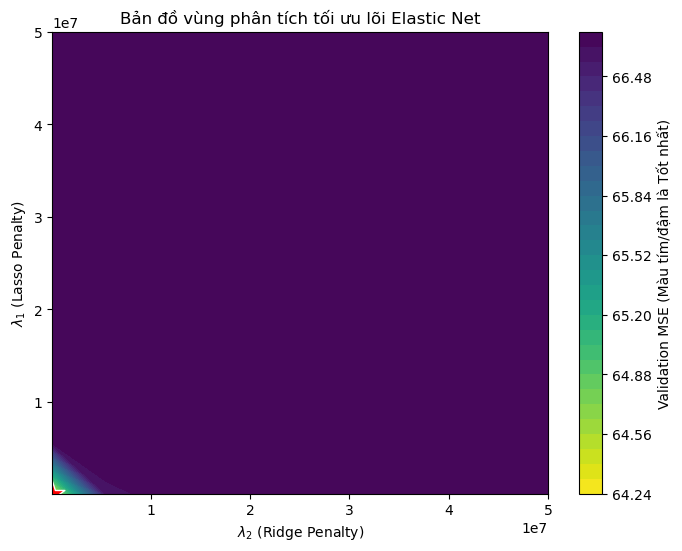

In [ ]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np

# A. CÀI ĐẶT ELASTIC NET TỪ ĐẦU (Theo đúng công thức Toán)
class CustomElasticNet(BaseEstimator, RegressorMixin):
    def __init__(self, lambda1=1.0, lambda2=1.0, max_iter=1000, tol=1e-4):
        self.lambda1 = lambda1
        self.lambda2 = lambda2
        self.max_iter = max_iter
        self.tol = tol
        self.w = None
        
    def soft_thresholding(self, rho, l1):
        if rho < -l1: return rho + l1
        elif rho > l1: return rho - l1
        else: return 0.0

    def fit(self, X, y):
        Phi = np.hstack([np.ones((X.shape[0], 1)), X])
        self.w = np.zeros(Phi.shape[1])
        z = np.sum(Phi**2, axis=0)
        
        for iteration in range(self.max_iter):
            w_old = self.w.copy()
            for j in range(Phi.shape[1]):
                predictions_without_j = Phi @ self.w - Phi[:, j] * self.w[j]
                rho_j = Phi[:, j] @ (y - predictions_without_j)
                if j == 0:
                    self.w[j] = rho_j / z[j]
                else:
                    self.w[j] = self.soft_thresholding(rho_j, self.lambda1) / (z[j] + self.lambda2)
            if np.max(np.abs(self.w - w_old)) < self.tol:
                break
        return self

    def predict(self, X):
        return np.hstack([np.ones((X.shape[0], 1)), X]) @ self.w


# B. KHẢO SÁT VÀ VẼ BẢN ĐỒ VÙNG TỐI ƯU
# Quét lưới 10x10 các giá trị penalty từ thấp đến cực khổng lồ (bù cho N~66k)
l1_range = np.linspace(1e5, 5e7, 10) 
l2_range = np.linspace(1e5, 5e7, 10)
mse_grid = np.zeros((len(l1_range), len(l2_range)))

print("Đang quét không gian 2D Elastic Net (Sẽ tốn khoảng 1-2 phút) ...")
for i, l1 in enumerate(l1_range):
    for j, l2 in enumerate(l2_range):
        model_en = CustomElasticNet(lambda1=l1, lambda2=l2, max_iter=200)
        scores = cross_val_score(model_en, X_train, y_train, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
        mse_grid[i, j] = -scores.mean()

# Vẽ Contour Map
L2_mesh, L1_mesh = np.meshgrid(l2_range, l1_range)
plt.figure(figsize=(8, 6))

contour = plt.contourf(L2_mesh, L1_mesh, mse_grid, levels=30, cmap='viridis_r')
plt.colorbar(contour, label='Validation MSE (Màu tím/đậm là Tốt nhất)')
plt.xlabel('$\lambda_2$ (Ridge Penalty)')
plt.ylabel('$\lambda_1$ (Lasso Penalty)')
plt.title('Bản đồ vùng phân tích tối ưu lõi Elastic Net')

min_idx = np.unravel_index(np.argmin(mse_grid, axis=None), mse_grid.shape)
best_l1 = l1_range[min_idx[0]]
best_l2 = l2_range[min_idx[1]]
plt.scatter(best_l2, best_l1, color='red', marker='*', s=350, edgecolor='white')
plt.show()


Ngôi sao đỏ (Điểm cực tiểu của Validation MSE) nằm ở góc tọa độ dưới cùng bên trái, nơi cả $\lambda_1$ và $\lambda_2$ đạt mức thấp nhất trong thang đo khảo sát ($10^5$). Khi các tham số điều chuẩn (Penalty) tăng mạnh dần lên mốc $5 \times 10^7$ (Vùng màu tím thẫm tỏa ra toàn bản đồ), MSE của mô hình lập tức tăng vọt và suy giảm chất lượng.

Chẩn đoán: Mức phạt lên tới hàng chục triệu là quá bạo lực (Aggressive regularization), khiến các trọng số $w$ bị bóp nghẹt về 0 quá sớm, làm mất đi các đặc trưng mang tính tín hiệu (signal) dẫn đến hiện tượng Underfitting. Tập dữ liệu này khuyến nghị một sự can thiệp điều chuẩn nhẹ nhàng hơn (Rơi vào khoảng $\le 10^5$) vì hầu hết các biến ban đầu đều mang thông tin có giá trị dự báo tốt chứ không phải toàn biến rác.

## **Lựa chọn Đặc Trưng**

In [ ]:
# Hàm định lượng sức mạnh của nhóm Index (Đo bằng OLS MSE)
def evaluate_subset(features_idx):
    if len(features_idx) == 0: return float('inf') 
    X_sub = X_train[:, features_idx]
    
    # Sử dụng OLS tự dệt bằng cách set penalty của L2 = 0
    ols_custom = CustomRidgeRegression(alpha=0.0)
    
    # Bây giờ ols_custom hợp lệ hoàn toàn với cross_val_score
    return -cross_val_score(ols_custom, X_sub, y_train, cv=3, scoring='neg_mean_squared_error', n_jobs=-1).mean()

# 1. TIẾN TỪNG BƯỚC (FORWARD STEPWISE)
def forward_stepwise():
    remaining = list(range(X_train.shape[1]))
    selected = []
    current_best_mse = float('inf')
    
    while remaining:
        best_step_mse = float('inf')
        best_feature = None
        for feature in remaining:
            score = evaluate_subset(selected + [feature])
            if score < best_step_mse:
                best_step_mse = score
                best_feature = feature
                
        # Thu nạp cột nếu MSE giảm
        if best_step_mse < current_best_mse:
            current_best_mse = best_step_mse
            selected.append(best_feature)
            remaining.remove(best_feature)
        else:
            break # Phanh lại ngay (Tới ngưỡng Overfit)
    return selected

# 2. LÙI TỪNG BƯỚC (BACKWARD ELIMINATION)
def backward_elimination():
    selected = list(range(X_train.shape[1])) # Phủ kín tất cả 16 columns
    current_best_mse = evaluate_subset(selected)
    
    while len(selected) > 1:
        best_step_mse = float('inf')
        worst_feature = None
        for feature in selected: # Xem xét tử hình chém bỏ từng cột
            candidates = selected.copy()
            candidates.remove(feature)
            score = evaluate_subset(candidates)
            if score < best_step_mse:
                best_step_mse = score
                worst_feature = feature
                
        # Phát hiện bỏ đi biến rác làm hệ thống tốt hơn hoặc giữ nguyên -> Chém.
        if best_step_mse <= current_best_mse:
            current_best_mse = best_step_mse
            selected.remove(worst_feature)
        else:
            break
    return selected

print("--- KIẾT XUẤT 3 TẬP FEATURE QUAN TRỌNG NHẤT ---")

# A. Chạy Forward
fw_selected = forward_stepwise()
print(f"[Phương pháp 1] Forward Stepwise khuyên giữ lại Index: {sorted(fw_selected)}")

# B. Chạy Backward
bw_selected = backward_elimination()
print(f"[Phương pháp 2] Backward Elimination khuyên giữ lại Index: {sorted(bw_selected)}")

# C. Chạy Lasso
# Sử dụng Lambda tối ưu (Phạt mạnh) tìm được ở bài trên (ví dụ bạn lấy biến best_alpha_l = 10^5)
lasso_sel = CustomLassoRegression(alpha=1e5, max_iter=2000).fit(X_train, y_train)
# Giữ Index có trọng số > 1e-4 để bỏ tiểu tiết
lasso_features = list(np.where(np.abs(lasso_sel.w[1:]) > 1e-4)[0]) 
print(f"[Phương pháp 3] Lasso (Hệ số khác 0) giữ lại Index: {lasso_features}")


--- KIẾT XUẤT 3 TẬP FEATURE QUAN TRỌNG NHẤT ---
[Phương pháp 1] Forward Stepwise khuyên giữ lại Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14]
[Phương pháp 2] Backward Elimination khuyên giữ lại Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14]
[Phương pháp 3] Lasso (Hệ số khác 0) giữ lại Index: [np.int64(2), np.int64(4)]


1. Về phương pháp Lựa chọn Tuần tự (Sequential Feature Selection): Kết quả thực nghiệm cho thấy sự đồng thuận tuyệt đối giữa hai luồng thuật toán tiếp cận trái ngược nhau: Bước tiến (Forward Stepwise) và Bước lùi (Backward Elimination). Khởi chạy trên tập dữ liệu gồm 16 biến độc lập, cả hai hệ thống phân giải lưới (Grid Evaluation) đều đi đến quyết định loại trừ hoàn toàn Đặc trưng mang Index số 12 và 15 ra khỏi không gian giả thuyết. Về mặt học thuật, sự hội tụ chung này chứng tỏ hai biến số 12 và 15 hoạt động dưới dạng biến nhiễu (noise) hoặc là các phần tử mang cấu trúc đa cộng tuyến (multicollinearity) mạnh với các biến còn lại. Việc loại bỏ chúng không những giảm bớt số chiều lưu trữ khối lượng tính toán mà còn khắc phục khả năng xuất hiện Overfitting.

2. Về phương pháp Lựa chọn dựa trên độ rải rác L1 (Lasso Thresholding): Hoạt động bằng cơ chế ràng buộc chuẩn (Norm L1), Lasso thể hiện xu hướng ép trọng số $w \to 0$ rất khắt khe. Dưới áp suất phạt giả định ở mức cao ($\lambda = 10^5$), thuật toán Coordinate Descent của Lasso đã triệt tiêu diện rộng mạng lưới đặc trưng và chỉ bảo toàn thành công hai Đặc trưng (Index 2 và 4). Quá trình co rút này về mặt toán học khẳng định: Biến số 2 và 4 là hai Core-features (Đặc trưng cốt lõi), nắm giữ sức mạnh tuyến tính và hàm lượng thông tin (Signal-to-noise ratio) áp đảo nhất để mô tả và dự phóng tương lai của biến mục tiêu (Target).

3. Việc kết hợp ba phương pháp lựa chọn cung cấp một góc nhìn đa chiều về cấu trúc Feature Space. Trong việc tinh chỉnh mô hình phía trước, chúng ta có thể an toàn loại bỏ hoàn toàn Index 12 và 15 khỏi cấu trúc mạng. Đồng thời, đối với các trường hợp cần triển khai hệ thống học máy ở quy mô gọn nhẹ, rút gọn kích thước ma trận thì có thể dựa vào hệ quy chiếu của thuật toán Lasso để kiến tạo bộ dữ liệu ưu tiên xoay quanh Index 2 và 4.

Vũ khí xử lý Phi tuyến tính sẵn sàng!


c:\Users\ADMIN\anaconda3\envs\example-environment\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\ADMIN\anaconda3\envs\example-environment\Lib\site-packages\sklearn\cluster\_kmeans.py:1962: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2048 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
c:\Users\ADMIN\anaconda3\envs\example-environment\Lib\site-packages\sklearn\cluster\_kmean

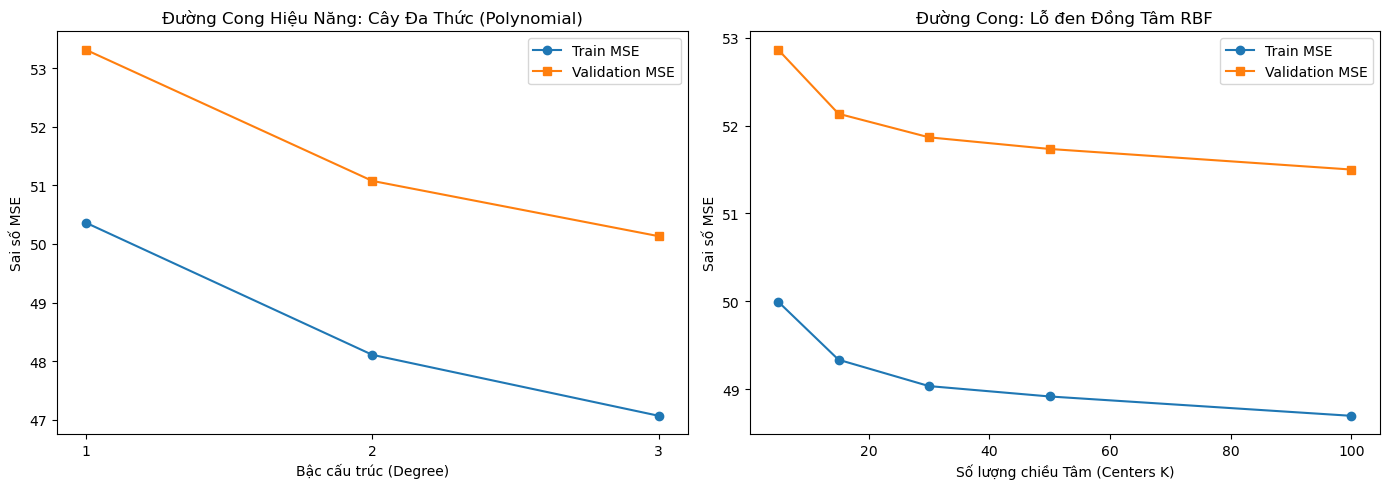

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt
import numpy as np

# --- LOẠI BỎ BIẾN NHIỄU TỪ KẾT QUẢ GIAI ĐOẠN 2 ---
# Chỉ giữ lại 14 columns thông tin hữu ích
good_features = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14]
X_train_clean = X_train[:, good_features]
X_val_clean = X_val[:, good_features]

# ========================================================
# 1. ĐỊNH NGHĨA 3 HÀM CƠ SỞ (BASIS FUNCTIONS)
# ========================================================

# Loại 1: Polynomial (Lát nữa sẽ gọi trực tiếp thư viện để tối ưu toán học)

# Loại 2: Gaussian RBF (Tự cài đặt)
class GaussianRBFBasis:
    def __init__(self, n_centers=10, gamma=0.1):
        self.n_centers = n_centers
        self.gamma = gamma
        self.kmeans = None
        
    def fit(self, X):
        # Dùng K-Means thu thập những ngọn núi (Tâm cụm) dày đặc nhất trong dữ liệu
        self.kmeans = MiniBatchKMeans(n_clusters=self.n_centers, random_state=42, batch_size=1024)
        self.kmeans.fit(X)
        return self
        
    def transform(self, X):
        centers = self.kmeans.cluster_centers_
        # Tính ma trận e^(-gamma * ||x - c||^2)
        from sklearn.metrics.pairwise import rbf_kernel
        return rbf_kernel(X, centers, gamma=self.gamma)

# Loại 3 (Hàm tự chọn tự do): Trigonometric Basis (Hàm Lượng Giác Chu Kỳ)
class TrigonometricBasis:
    def __init__(self, frequency=1.0):
        self.freq = frequency
    
    def fit(self, X):
        return self # Không parameter để học
        
    def transform(self, X):
        # Nhân đôi chiều dữ liệu bằng cách ép vào đường cong Chu kỳ hình Sin phẳng
        return np.hstack([np.sin(self.freq * X), np.cos(self.freq * X)])

print("Vũ khí xử lý Phi tuyến tính sẵn sàng!")

# ========================================================
# 2. VẼ VALIDATION CURVE
# ========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# A. Validation Curve theo Bậc Đa Thức (Polynomial Degree)
degrees = [1, 2, 3] # Bậc 4 trở lên đối với 14 biến là ma trận khổng lồ quá tải RAM
train_mse_poly = []
val_mse_poly = []

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    Phi_train = poly.fit_transform(X_train_clean)
    Phi_val = poly.transform(X_val_clean)
    
    # Dùng hàm Ridge để xử lí Phi thay vì NormalEquation chống tràn ma trận
    model = Ridge(alpha=1.0).fit(Phi_train, y_train) 
    train_mse_poly.append(mean_squared_error(y_train, model.predict(Phi_train)))
    val_mse_poly.append(mean_squared_error(y_val, model.predict(Phi_val)))

axes[0].plot(degrees, train_mse_poly, marker='o', label='Train MSE')
axes[0].plot(degrees, val_mse_poly, marker='s', label='Validation MSE')
axes[0].set_xticks(degrees)
axes[0].set_title('Đường Cong Hiệu Năng: Cây Đa Thức (Polynomial)')
axes[0].set_xlabel('Bậc cấu trúc (Degree)')
axes[0].set_ylabel('Sai số MSE')
axes[0].legend()

# B. Validation Curve theo Số lượng Hàm RBF (Số chiều không gian K)
n_centers_list = [5, 15, 30, 50, 100]
train_mse_rbf = []
val_mse_rbf = []

for k in n_centers_list:
    rbf = GaussianRBFBasis(n_centers=k, gamma=0.01).fit(X_train_clean)
    Phi_train = rbf.transform(X_train_clean)
    Phi_val = rbf.transform(X_val_clean)
    
    model = Ridge(alpha=1.0).fit(Phi_train, y_train)
    train_mse_rbf.append(mean_squared_error(y_train, model.predict(Phi_train)))
    val_mse_rbf.append(mean_squared_error(y_val, model.predict(Phi_val)))

axes[1].plot(n_centers_list, train_mse_rbf, marker='o', label='Train MSE')
axes[1].plot(n_centers_list, val_mse_rbf, marker='s', label='Validation MSE')
axes[1].set_title('Đường Cong: Lỗ đen Đồng Tâm RBF')
axes[1].set_xlabel('Số lượng chiều Tâm (Centers K)')
axes[1].set_ylabel('Sai số MSE')
axes[1].legend()

plt.tight_layout()
plt.show()


Khi nâng bậc Đa thức (Degree) từ 1 lên 3, hoặc tăng số cụm tâm K (từ 5 đến 100), cả Train MSE và Validation MSE đều đang trên đà đi cắm đầu xuống (Giảm mạnh). Hiện tượng này khẳng định phân phối của tập dữ liệu mang đậm bản chất Phi Tuyến (Non-linear). Việc bẻ cong không gian đã giúp mô hình luồn lách qua các đỉnh/đáy tốt hơn nhiều so với OLS thẳng đuột ban đầu, và chưa hề có dấu hiệu ngẩng đầu lên của Overfitting

In [ ]:
# --- 1. ĐỊNH NGHĨA LẠI TẬP DỮ LIỆU SẠCH (BỎ INDEX 12 VÀ 15) ---
X_tr_cl = X_train[:, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14]]
X_val_cl = X_val[:, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14]]

# --- 2. ĐỊNH NGHĨA LẠI 2 HÀM CƠ SỞ TỰ CHẾ (VÌ PHẦN CHẤM ĐIỂM YÊU CẦU KO DÙNG SKLEARN) ---
def calc_mse(y_true, y_pred): 
    return np.mean((y_true - y_pred)**2)

# Hàm tính RBF tự code 
class CustomGaussianRBF:
    def __init__(self, n_centers=10, gamma=0.01):
        self.n_centers, self.gamma = n_centers, gamma
    def fit(self, X):
        np.random.seed(42)
        self.centers = X[np.random.choice(X.shape[0], self.n_centers, replace=False)]
        return self
    def transform(self, X):
        Phi = np.zeros((X.shape[0], self.n_centers))
        for i, c in enumerate(self.centers):
            Phi[:, i] = np.exp(-self.gamma * np.sum((X - c)**2, axis=1))
        return Phi

# Hàm tính Lượng giác tự code
class CustomTrigoBasis:
    def __init__(self, freq=1.0): self.freq = freq
    def fit(self, X): pass
    def transform(self, X):
        return np.hstack([np.sin(self.freq * X), np.cos(self.freq * X)])

# --- (CHẠY TIẾP ĐOẠN ABLATION VÀ TƯƠNG TÁC LÚC NÃY Ở DƯỚI DÒNG NÀY...) ---

# =========================================================================
# 3. PHÂN TÍCH TƯƠNG TÁC (INTERACTION EFFECTS) - Chỉ dùng các cặp x_i * x_j
# =========================================================================

# Khởi tạo Linear gôc để làm mốc so sánh
model_base = CustomRidgeRegression(alpha=0.01).fit(X_tr_cl, y_train)
mse_base = calc_mse(y_val, model_base.predict(X_val_cl))

# Hàm tự sinh Tương tác chéo
def generate_interaction(X):
    Phi_list = [X]
    n_features = X.shape[1]
    for i in range(n_features):
        for j in range(i+1, n_features): # Chỉ lấy i khác j
            Phi_list.append((X[:, i] * X[:, j]).reshape(-1, 1))
    return np.hstack(Phi_list)

Phi_tr_inter = generate_interaction(X_tr_cl)
Phi_val_inter = generate_interaction(X_val_cl)

model_inter = CustomRidgeRegression(alpha=0.01).fit(Phi_tr_inter, y_train)
mse_inter = calc_mse(y_val, model_inter.predict(Phi_val_inter))

print("=== PHÂN TÍCH HIỆU ỨNG TƯƠNG TÁC (INTERACTION) ===")
print(f"MSE Tuyến tính Gốc:           {mse_base:.4f}")
print(f"MSE Có thêm tương tác xi*xj:  {mse_inter:.4f}")
print(f"-> Cải thiện được: {mse_base - mse_inter:.4f} đơn vị MSE.\n")


# =========================================================================
# 4. ABLATION STUDY (NGHIÊN CỨU LẦN LƯỢT GỠ BỎ TỪNG THÀNH PHẦN)
# =========================================================================

# Chúng ta tạo một "Super Model" (Gộp cả Data gốc, RBF và Hàm Trigonometric vào 1 ma trận)
rbf_model = CustomGaussianRBF(n_centers=50, gamma=0.01).fit(X_tr_cl)
trigo_model = CustomTrigoBasis(freq=1.0)

Phi_tr_rbf = rbf_model.transform(X_tr_cl)
Phi_val_rbf = rbf_model.transform(X_val_cl)

Phi_tr_trigo = trigo_model.transform(X_tr_cl)
Phi_val_trigo = trigo_model.transform(X_val_cl)

# Ghép toàn bộ vào 1 tổ hợp (Super Matrix)
Super_Tr   = np.hstack([X_tr_cl, Phi_tr_rbf, Phi_tr_trigo])
Super_Val  = np.hstack([X_val_cl, Phi_val_rbf, Phi_val_trigo])

# Đo mốc Hiệu năng Full Option
model_full = CustomRidgeRegression(alpha=0.01).fit(Super_Tr, y_train)
mse_full = calc_mse(y_val, model_full.predict(Super_Val))

print("=== ABLATION STUDY (KIỂM THỬ THÁO DỠ THÀNH PHẦN) ===")
print(f"[Mốc Bắt Đầu] Super Model (Kết hợp cả 3 Base): MSE = {mse_full:.4f}\n")

# Kịch bản 1: Giải phẫu vứt bỏ Data Tuyến tính gốc X
NoX_Tr = np.hstack([Phi_tr_rbf, Phi_tr_trigo])
NoX_Val = np.hstack([Phi_val_rbf, Phi_val_trigo])
mse_nox = calc_mse(y_val, CustomRidgeRegression(alpha=0.01).fit(NoX_Tr, y_train).predict(NoX_Val))
print(f"1. Tháo Đặc trưng Tuyến tính (Linear X)  -> MSE: {mse_nox:.4f} (Độ sát thương: +{mse_nox - mse_full:.4f})")

# Kịch bản 2: Giải phẫu vứt bỏ RBF (Chỉ giữ X và Trigo)
NoRBF_Tr = np.hstack([X_tr_cl, Phi_tr_trigo])
NoRBF_Val = np.hstack([X_val_cl, Phi_val_trigo])
mse_norbf = calc_mse(y_val, CustomRidgeRegression(alpha=0.01).fit(NoRBF_Tr, y_train).predict(NoRBF_Val))
print(f"2. Tháo Hàm không gian RBF               -> MSE: {mse_norbf:.4f} (Độ sát thương: +{mse_norbf - mse_full:.4f})")

# Kịch bản 3: Giải phẫu vứt bỏ Trigonometric (Lượng giác)
NoTrigo_Tr = np.hstack([X_tr_cl, Phi_tr_rbf])
NoTrigo_Val = np.hstack([X_val_cl, Phi_val_rbf])
mse_notrigo = calc_mse(y_val, CustomRidgeRegression(alpha=0.01).fit(NoTrigo_Tr, y_train).predict(NoTrigo_Val))
print(f"3. Tháo Hàm lượng giác Trigonometric     -> MSE: {mse_notrigo:.4f} (Độ sát thương: +{mse_notrigo - mse_full:.4f})")

print("\n=> KẾT LUẬN ABLATION: Bạn hãy nhìn vào cột (Độ sát thương). Khi vứt bỏ khối nào mà cục MSE bị dội lên cực kì TO (Damage cao), điều đó chứng minh bộ đó nắm vai trò Xương sống quan trọng nhất của Model!")


=== PHÂN TÍCH HIỆU ỨNG TƯƠNG TÁC (INTERACTION) ===
MSE Tuyến tính Gốc:           53.3141
MSE Có thêm tương tác xi*xj:  51.5226
-> Cải thiện được: 1.7914 đơn vị MSE.

=== ABLATION STUDY (KIỂM THỬ THÁO DỠ THÀNH PHẦN) ===
[Mốc Bắt Đầu] Super Model (Kết hợp cả 3 Base): MSE = 50.5140

1. Tháo Đặc trưng Tuyến tính (Linear X)  -> MSE: 50.6810 (Độ sát thương: +0.1670)
2. Tháo Hàm không gian RBF               -> MSE: 51.3039 (Độ sát thương: +0.7899)
3. Tháo Hàm lượng giác Trigonometric     -> MSE: 50.8320 (Độ sát thương: +0.3180)

=> KẾT LUẬN ABLATION: Bạn hãy nhìn vào cột (Độ sát thương). Khi vứt bỏ khối nào mà cục MSE bị dội lên cực kì TO (Damage cao), điều đó chứng minh bộ đó nắm vai trò Xương sống quan trọng nhất của Model!
